# 4.1 Generate synthetic data (Y) following any type of distributions

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# reproducibility (Каждый раз при запуске у тебя получится одинаковый массив Y, одинаковое среднее, одинаковая оптимальная c.)
np.random.seed(42)

In [4]:
# synthetic data - normal distribution with mean=5, std=2, 100 samples
Y = np.random.normal(loc=5, scale=2, size=100)

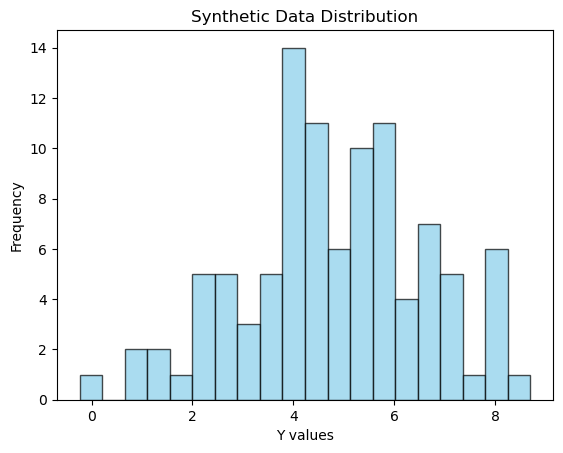

array([ 5.99342831,  4.7234714 ,  6.29537708,  8.04605971,  4.53169325,
        4.53172609,  8.15842563,  6.53486946,  4.06105123,  6.08512009,
        4.07316461,  4.06854049,  5.48392454,  1.17343951,  1.55016433,
        3.87542494,  2.97433776,  5.62849467,  3.18395185,  2.1753926 ,
        7.93129754,  4.5484474 ,  5.13505641,  2.15050363,  3.91123455,
        5.22184518,  2.69801285,  5.75139604,  3.79872262,  4.4166125 ,
        3.79658678,  8.70455637,  4.97300555,  2.88457814,  6.64508982,
        2.5583127 ,  5.41772719,  1.08065975,  2.3436279 ,  5.39372247,
        6.47693316,  5.34273656,  4.76870344,  4.39779261,  2.04295602,
        3.56031158,  4.07872246,  7.11424445,  5.68723658,  1.47391969,
        5.64816794,  4.22983544,  3.646156  ,  6.22335258,  7.06199904,
        6.86256024,  3.32156495,  4.38157525,  5.66252686,  6.95109025,
        4.04165152,  4.62868205,  2.78733005,  2.60758675,  6.62505164,
        7.71248006,  4.85597976,  7.0070658 ,  5.72327205,  3.70

In [5]:
plt.hist(Y, bins=20, alpha=0.7, color="skyblue", edgecolor="black")
plt.title("Synthetic Data Distribution")
plt.xlabel("Y values")
plt.ylabel("Frequency")
plt.show()
Y

# 4.2 Create an array of different values for the constant c (e.g., from 0 to 10). Calculate the MSE for each value of c.

In [6]:
c_values = np.linspace(0, 10, 100)  # values of c from 0 to 10
mse_values = []

In [7]:
for c in c_values:
    mse = np.mean((Y - c) ** 2)  
    mse_values.append(mse)

mse_values = np.array(mse_values)
mse_values

array([26.23229483, 25.27435505, 24.33682135, 23.41969373, 22.52297219,
       21.64665673, 20.79074736, 19.95524406, 19.14014685, 18.34545572,
       17.57117067, 16.8172917 , 16.08381881, 15.370752  , 14.67809127,
       14.00583662, 13.35398806, 12.72254557, 12.11150917, 11.52087885,
       10.9506546 , 10.40083644,  9.87142436,  9.36241837,  8.87381845,
        8.40562461,  7.95783686,  7.53045518,  7.12347959,  6.73691008,
        6.37074665,  6.0249893 ,  5.69963803,  5.39469284,  5.11015373,
        4.8460207 ,  4.60229376,  4.37897289,  4.17605811,  3.99354941,
        3.83144679,  3.68975025,  3.56845979,  3.46757541,  3.38709711,
        3.3270249 ,  3.28735876,  3.26809871,  3.26924473,  3.29079684,
        3.33275503,  3.3951193 ,  3.47788965,  3.58106608,  3.7046486 ,
        3.84863719,  4.01303186,  4.19783262,  4.40303946,  4.62865238,
        4.87467137,  5.14109645,  5.42792762,  5.73516486,  6.06280818,
        6.41085758,  6.77931307,  7.16817464,  7.57744228,  8.00

# 4.3 Find the optimal c, compare it to the mean of your synthetic dataset

In [8]:
optimal_index = np.argmin(mse_values)
optimal_c = c_values[optimal_index]
mean_Y = np.mean(Y)

print("Optimal c (minimizes MSE):", optimal_c)
print("Mean of Y:", mean_Y)

Optimal c (minimizes MSE): 4.747474747474747
Mean of Y: 4.792306965211812


# 4.4 Plot the MSE values against the different values of c. Mark the optimal c on the plot.

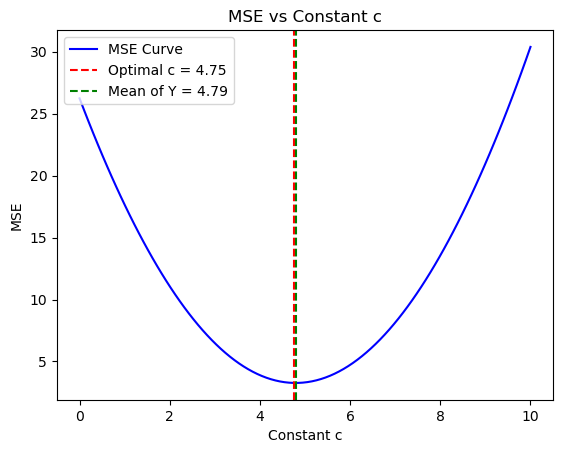

In [9]:
plt.plot(c_values, mse_values, label="MSE Curve", color="blue")
plt.axvline(optimal_c, color="red", linestyle="--", label=f"Optimal c = {optimal_c:.2f}")
plt.axvline(mean_Y, color="green", linestyle="--", label=f"Mean of Y = {mean_Y:.2f}")
plt.title("MSE vs Constant c")
plt.xlabel("Constant c")
plt.ylabel("MSE")
plt.legend()
plt.show()

# 4.5 Based on your final plot, what does the shape of the MSE curve tell you about the relationship between the constant c and the model’s error? Why does the MSE increase as c moves away from the mean of your data?

#### • 1: The MSE curve is shaped like a parabola (U-shape).
#### • 2: This happens because MSE is quadratic with respect to the constant 𝑐.
#### • 3: The minimum point of the parabola occurs when 𝑐 equals the mean of the dataset.
#### • 4: As 𝑐 moves away from the mean, the squared differences grow, which makes the MSE larger.

# 4.6 In your opinion, why might a simple dummy model be useful even when we have access to more powerful and complex machine learning algorithms?

#### • 1: Baseline: A constant predictor (mean) gives us a baseline error level. If a complex model cannot beat this, it’s not useful.
#### • 2: Interpretability: It helps us understand the data’s central tendency.
#### • 3: Robustness check: Sometimes, the dummy model is already “good enough” (e.g., in imbalanced datasets predicting the majority class).
#### • 4: Comparison metric: Provides a reference point for improvement when evaluating more sophisticated models.

# Bonus: Write your own implementation of splitting the dataset on train and test using shuffling

In [10]:
import numpy as np

def train_test_split(X, y, test_size=0.2, random_state=None):
    """
    Split the dataset into training and testing sets.

    Parameters:
    X (numpy array): The feature matrix.
    y (numpy array): The target labels.
    test_size (float): The proportion of the dataset to include in the test split.
    random_state (int, optional): Seed for reproducibility.

    Returns:
    X_train (numpy array): The training feature matrix.
    X_test (numpy array): The testing feature matrix.
    y_train (numpy array): The training labels.
    y_test (numpy array): The testing labels.
    """
    if random_state is not None:
        np.random.seed(random_state)

    # number of samples
    n_samples = len(X)
    
    # generate shuffled indices
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    # split point
    test_size_count = int(n_samples * test_size)
    test_indices = indices[:test_size_count]
    train_indices = indices[test_size_count:]

    # split X and y
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test


# Example usage
X = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
y = np.array([0, 1, 0, 1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("X_train:\n", X_train)
print("X_test:\n", X_test)
print("y_train:", y_train)
print("y_test:", y_test)

X_train:
 [[7 8]
 [1 2]
 [5 6]]
X_test:
 [[3 4]]
y_train: [1 0 0]
y_test: [1]
